# 05 · Текстові моделі: fine-tuning трансформера

У бейзлайні текст — найслабша модальність: TF-IDF + Ridge дає OOF QWK ≈ 0.335, заморожені
ембедінги `bge-m3` + Ridge — лише ≈ 0.29. Тому донавчаємо трансформер на регресію
`AdoptionSpeed` на тих самих 5 фолдах і додаємо його OOF-передбачення як ознаку в стекінг.

**Модель:** `microsoft/deberta-v3-base` — mean pooling + лінійна голова, dropout вимкнено
(для регресії це стабільніше), AdamW + cosine warmup, bf16, `max_len=256`
(90% описів коротші за 204 токени). Оцінка 2 рази за епоху, беремо найкращий чекпойнт
за val RMSE.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder
from src.models import run_lgb_cv

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
import torch
from src.text import TextConfig, run_text_cv

train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y, folds, n_tr = train[TARGET_COL].values.astype(float), train["fold"].values, len(train)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device, torch.cuda.get_device_name(0) if device == "cuda" else "")

cuda NVIDIA GeForce RTX 4080 Laptop GPU


## 1. Конфігурація експерименту

In [3]:
cfg = TextConfig(
    model_name="microsoft/deberta-v3-base",
    max_len=256,
    batch_size=16,
    epochs=3,
    lr=2e-5,
    head_lr=1e-3,
    evals_per_epoch=2,
)
cfg

TextConfig(model_name='microsoft/deberta-v3-base', max_len=256, batch_size=16, epochs=3, lr=2e-05, head_lr=0.001, weight_decay=0.01, warmup_ratio=0.1, evals_per_epoch=2, grad_checkpointing=False, seed=42)

## 2. Крос-валідація (~22 хв на RTX 4080 Laptop)

In [4]:
oof, pred_te, history = run_text_cv(train, test, cfg, device=device)

rounder = OptimizedRounder().fit(oof, y)
print(f"\nOOF QWK: {qwk(y, rounder.predict(oof)):.4f}   RMSE: {np.sqrt(np.mean((oof - y) ** 2)):.4f}")

tag = "text_" + cfg.model_name.split("/")[-1]
np.save(PROCESSED_DIR / f"oof_{tag}.npy", oof)
np.save(PROCESSED_DIR / f"test_{tag}.npy", pred_te)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 0: best val rmse 1.0531  fold QWK 0.3773  (4.5 min)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

fold 3: best val rmse 1.0710  fold QWK 0.3609  (3.3 min)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 4: best val rmse 1.0384  fold QWK 0.3785  (3.3 min)



OOF QWK: 0.3445   RMSE: 1.0512


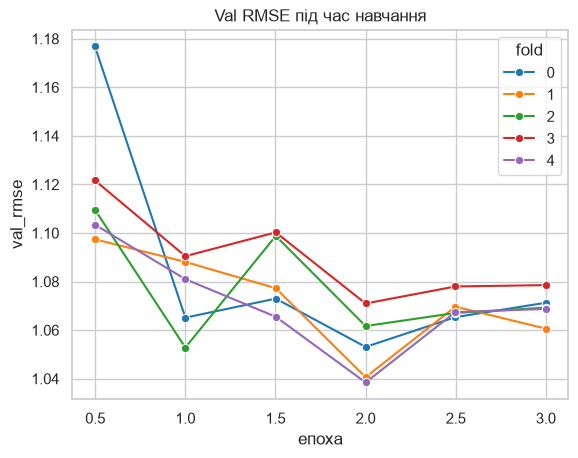

In [5]:
ax = sns.lineplot(data=history, x="epoch", y="val_rmse", hue="fold", marker="o", palette="tab10")
ax.set(title="Val RMSE під час навчання", xlabel="епоха");

## 3. Чи додає трансформер щось до бейзлайну?

Ручні ознаки 02/03 + OOF Ridge з 04 → LightGBM, з і без OOF трансформера.
(SVD/PCA тут пропускаємо — у 04 вони майже нічого не дали.)

In [6]:
def load_feats(name: str) -> pd.DataFrame:
    return pd.concat([pd.read_parquet(PROCESSED_DIR / f"{name}_{s}.parquet") for s in ("train", "test")],
                     ignore_index=True).drop(columns=ID_COL)

def load_pred(name: str) -> np.ndarray:
    return np.r_[np.load(PROCESSED_DIR / f"oof_{name}.npy"), np.load(PROCESSED_DIR / f"test_{name}.npy")]

n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
ridge = pd.DataFrame({k: load_pred(k) for k in ["ridge_clip_img", "ridge_tfidf", "ridge_clip_text"]})
base = pd.concat([n_photos, load_feats("text_feats"), load_feats("img_feats"), ridge], axis=1)
with_text = base.assign(**{tag: load_pred(tag)})

rows = []
for name, X in [("бейзлайн (без трансформера)", base), ("+ OOF DeBERTa", with_text)]:
    res = run_lgb_cv(X[:n_tr], X[n_tr:], y, folds, verbose=False)
    rows.append({"ознаки": name, "OOF QWK": res["qwk"]})
pd.DataFrame(rows).round(4)

,ознаки,OOF QWK
0,бейзлайн (без трансформера),0.6064
1,+ OOF DeBERTa,0.6112


In [7]:
# Correlation between level-1 models: the less correlated, the more stacking gains
pd.DataFrame({k: load_pred(k)[:n_tr] for k in ["ridge_clip_img", "ridge_tfidf", "ridge_clip_text", tag]}).corr().round(3)

,ridge_clip_img,ridge_tfidf,ridge_clip_text,text_deberta-v3-base
ridge_clip_img,1.000,0.466,0.443,0.439
ridge_tfidf,0.466,1.000,0.601,0.678
ridge_clip_text,0.443,0.601,1.000,0.578
text_deberta-v3-base,0.439,0.678,0.578,1.000


## Висновки

- **Fine-tuning DeBERTa-v3-base:** OOF QWK **0.3445** (по фолдах 0.30–0.38), ~18 хв на 5 фолдів.
  Лише трохи краще за TF-IDF + Ridge (0.335) і помітно краще за заморожені ембедінги bge-m3 + Ridge (0.29).
  Найкращий чекпойнт — кінець 2-ї епохи, далі перенавчання.
- **У стекінгу приріст на рівні шуму:** 0.606 → 0.611. Передбачення DeBERTa корелюють з TF-IDF-моделлю
  на 0.68 — трансформер вловлює приблизно те саме, що й n-грами.
- **Висновок:** у цій задачі стеля тексту ~0.35; головний сигнал — у фото, тож подальші зусилля пішли туди.
- Технічна пастка: transformers 5 завантажує DeBERTa-v3 у fp16 (як у чекпойнті), і AdamW на fp16-вагах
  розходиться в NaN — ваги треба вантажити у fp32 (обчислення — у bf16 через autocast).